# Task 1: Titanic Dataset Data Cleaning and Preprocessing
**Author**: Pragna (Intern, Synent Technologies)  
**Objective**: Prepare raw, messy Titanic survival records for downstream analytical tasks by performing rigorous data cleaning, null imputation, type casting, column standardizations, and outlier investigations.


## 1. Import Libraries and Load Dataset
In this section, we load the required scientific libraries and the raw Titanic CSV dataset into a Pandas DataFrame.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Set aesthetic styling for charts
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

# Load the raw Titanic dataset
raw_df = pd.read_csv("dataset/titanic_raw.csv")
print("Raw dataset loaded successfully!")
print(f"Shape of the dataset: {raw_df.shape[0]} rows, {raw_df.shape[1]} columns")


Raw dataset loaded successfully!
Shape of the dataset: 891 rows, 12 columns


Let's view the first few records of our raw data to inspect the column structures and format.


In [2]:
raw_df.head()


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


## 2. Initial Data Inspection & Profiling
We run profiling functions to understand the data types, non-null counts, and fundamental statistical metrics of the variables.


In [3]:
raw_df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


Let's run descriptive statistics to observe the spread, mean, medians, and outliers of the numeric columns.


In [4]:
raw_df.describe(include='all')


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
count,891.000000,891.000000,891.000000,891,891,714.000000,891.000000,891.000000,891,891.000000,204,889
unique,NaN,NaN,NaN,891,2,NaN,NaN,NaN,681,NaN,147,3
top,NaN,NaN,NaN,"Braund, Mr. Owen Harris",male,NaN,NaN,NaN,347082,NaN,G6,S
freq,NaN,NaN,NaN,1,577,NaN,NaN,NaN,7,NaN,4,644
mean,446.000000,0.383838,2.308642,NaN,NaN,29.699118,0.523008,0.381594,NaN,32.204208,NaN,NaN
std,257.353842,0.486592,0.836071,NaN,NaN,14.526497,1.102743,0.806057,NaN,49.693429,NaN,NaN
min,1.000000,0.000000,1.000000,NaN,NaN,0.420000,0.000000,0.000000,NaN,0.000000,NaN,NaN
25%,223.500000,0.000000,2.000000,NaN,NaN,20.125000,0.000000,0.000000,NaN,7.910400,NaN,NaN
50%,446.000000,0.000000,3.000000,NaN,NaN,28.000000,0.000000,0.000000,NaN,14.454200,NaN,NaN
75%,668.500000,1.000000,3.000000,NaN,NaN,38.000000,1.000000,0.000000,NaN,31.000000,NaN,NaN


## 3. Null Value Analysis
Before making modifications, we must analyze the distribution and severity of null (missing) values across the columns.


In [5]:
# Missing count and percentages
null_counts = raw_df.isnull().sum()
null_percent = (raw_df.isnull().sum() / len(raw_df)) * 100
missing_summary = pd.DataFrame({'Null Count': null_counts, 'Percentage (%)': null_percent})
missing_summary = missing_summary[missing_summary['Null Count'] > 0].sort_values(by='Null Count', ascending=False)
print("Summary of columns containing missing values:")
missing_summary


Summary of columns containing missing values:


,Null Count,Percentage (%)
Cabin,687,77.104377
Age,177,19.865320
Embarked,2,0.224467


Let's visualize the missing data distribution using a missing value heatmap. This provides a geographical map of where data is absent.


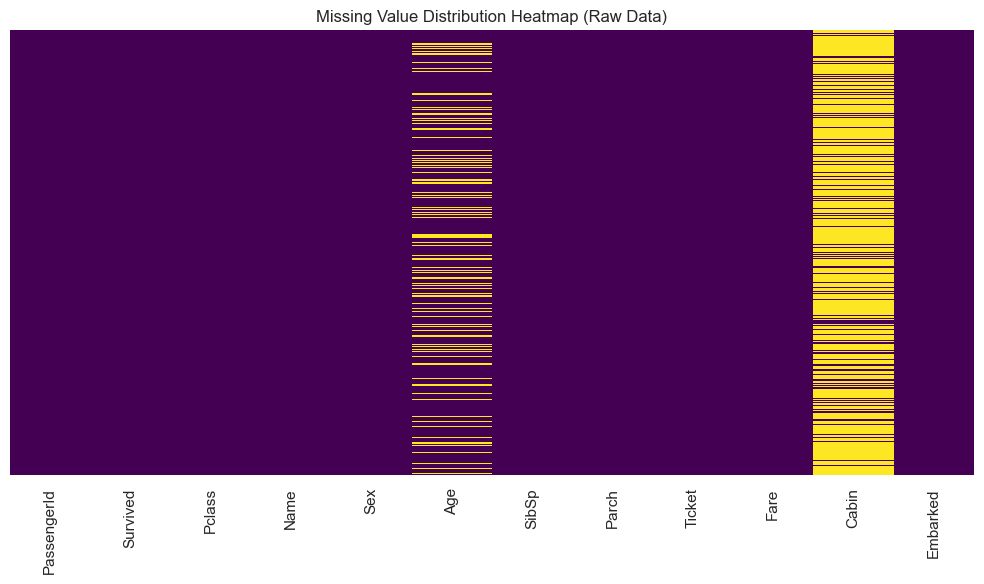

In [6]:
# Plotting missing values heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(raw_df.isnull(), yticklabels=False, cbar=False, cmap='viridis')
plt.title('Missing Value Distribution Heatmap (Raw Data)')
plt.tight_layout()
os.makedirs("images", exist_ok=True)
plt.savefig('images/missing_values_heatmap.png', dpi=100)
plt.show()


## 4. Duplicate Check
Duplicate rows can artificially skew analytical insights. We perform a check to see if duplicate records exist.


In [7]:
duplicates = raw_df.duplicated().sum()
print(f"Number of duplicate records found: {duplicates}")
if duplicates > 0:
    raw_df = raw_df.drop_duplicates()
    print("Duplicate rows successfully dropped.")


Number of duplicate records found: 0


## 5. Handling Missing Values
Based on our profiling, we apply targeted strategies for each column with missing values:
1. **Embarked**: Only 2 records are missing. We impute these using the mode (most common value).
2. **Age**: Has 177 missing values. Instead of filling with a global average, we group the passengers by passenger class (`Pclass`) and `Sex`, and impute missing ages with the median age of their respective cohort. This captures natural age differences (e.g. 1st class passengers are on average older).
3. **Cabin**: Over 77% of this column is null. Imputing it would introduce high noise. However, the presence of a Cabin number might indicate socio-economic class. We create a binary flag `has_cabin` (1 if Cabin is present, 0 otherwise) and then drop the high-null original column.


In [8]:
# 1. Impute Embarked with its Mode
embarked_mode = raw_df['Embarked'].mode()[0]
raw_df['Embarked'].fillna(embarked_mode, inplace=True)
print(f"Imputed missing Embarked values with Mode: {embarked_mode}")

# 2. Impute Age based on Class and Sex medians
raw_df['Age'] = raw_df.groupby(['Pclass', 'Sex'])['Age'].transform(lambda x: x.fillna(x.median()))
print("Imputed missing Age values using grouped medians.")

# 3. Handle Cabin: Create indicator and drop original
raw_df['has_cabin'] = raw_df['Cabin'].apply(lambda x: 0 if pd.isnull(x) else 1)
raw_df.drop(columns=['Cabin'], inplace=True)
print("Transformed 'Cabin' to binary feature 'has_cabin' and dropped the raw column.")

# Verify remaining missing values
print(f"Total remaining missing values: {raw_df.isnull().sum().sum()}")


Imputed missing Embarked values with Mode: S
Imputed missing Age values using grouped medians.
Transformed 'Cabin' to binary feature 'has_cabin' and dropped the raw column.
Total remaining missing values: 0


C:\Users\PRAGNA\AppData\Local\Temp\ipykernel_1068\3335299783.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  raw_df['Embarked'].fillna(embarked_mode, inplace=True)


## 6. Data Type Conversions & Standardizing Columns
To ensure our features use correct and optimal types, we cast our variables into categories or integers. We also rename columns to clean snake_case conventions.


In [9]:
# Casting categories
raw_df['Survived'] = raw_df['Survived'].astype('category')
raw_df['Pclass'] = raw_df['Pclass'].astype('category')
raw_df['Sex'] = raw_df['Sex'].astype('category')
raw_df['Embarked'] = raw_df['Embarked'].astype('category')

# Convert age to int for clean distributions
raw_df['Age'] = raw_df['Age'].round().astype(int)

# Standardize columns to snake_case
raw_df.rename(columns={
    'PassengerId': 'passenger_id',
    'Survived': 'survived',
    'Pclass': 'pclass',
    'Name': 'name',
    'Sex': 'sex',
    'Age': 'age',
    'SibSp': 'sib_sp',
    'Parch': 'parch',
    'Ticket': 'ticket',
    'Fare': 'fare',
    'Embarked': 'embarked'
}, inplace=True)

print("Standardized schema:")
raw_df.info()


Standardized schema:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype   
---  ------        --------------  -----   
 0   passenger_id  891 non-null    int64   
 1   survived      891 non-null    category
 2   pclass        891 non-null    category
 3   name          891 non-null    object  
 4   sex           891 non-null    category
 5   age           891 non-null    int64   
 6   sib_sp        891 non-null    int64   
 7   parch         891 non-null    int64   
 8   ticket        891 non-null    object  
 9   fare          891 non-null    float64 
 10  embarked      891 non-null    category
 11  has_cabin     891 non-null    int64   
dtypes: category(4), float64(1), int64(5), object(2)
memory usage: 59.8+ KB


## 7. Outlier Detection & Analysis
We investigate outliers in continuous variables `age` and `fare` using the Interquartile Range (IQR) method and display boxplots.


In [10]:
# Outlier analysis helper function
def analyze_outliers(df, col):
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr
    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
    return lower_bound, upper_bound, outliers

age_lb, age_ub, age_outliers = analyze_outliers(raw_df, 'age')
fare_lb, fare_ub, fare_outliers = analyze_outliers(raw_df, 'fare')

print(f"Age IQR Bounds: [{age_lb}, {age_ub}]. Found {len(age_outliers)} outliers.")
print(f"Fare IQR Bounds: [{fare_lb}, {fare_ub}]. Found {len(fare_outliers)} outliers.")


Age IQR Bounds: [1.0, 57.0]. Found 34 outliers.
Fare IQR Bounds: [-26.724, 65.6344]. Found 116 outliers.


Let's visualize the spreads and outlier points with boxplots.


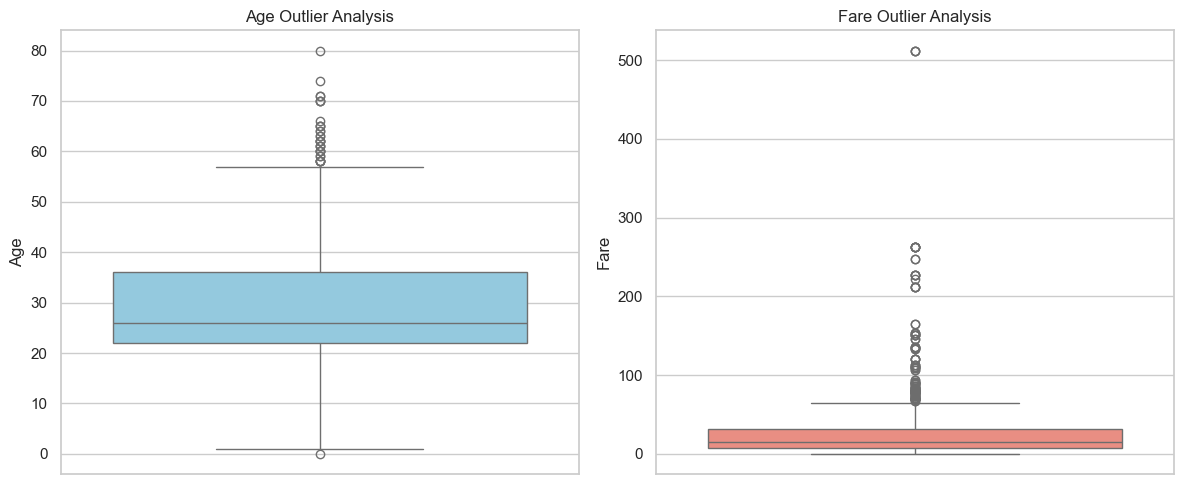

In [11]:
# Plotting outliers boxplots
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.boxplot(y=raw_df['age'], color='skyblue')
plt.title('Age Outlier Analysis')
plt.ylabel('Age')

plt.subplot(1, 2, 2)
sns.boxplot(y=raw_df['fare'], color='salmon')
plt.title('Fare Outlier Analysis')
plt.ylabel('Fare')

plt.tight_layout()
plt.savefig('images/outliers_boxplot.png', dpi=100)
plt.show()


### Note on Outlier Handling Strategy
1. **Age**: Outliers represent elderly individuals. These are entirely realistic and realistic human values, so we preserve them.
2. **Fare**: Outliers show values reaching as high as 512. In normal circumstances, statistical outliers might be removed, but on the Titanic, premium 1st class tickets genuinely cost this much. These passengers are highly correlated with high survival rates. Dropping them would delete crucial predictive information. Thus, we decide to retain these socioeconomic outliers.


## 8. Analyzing Feature Distributions
Let's plot the distribution profiles for Age and Fare after cleaning.


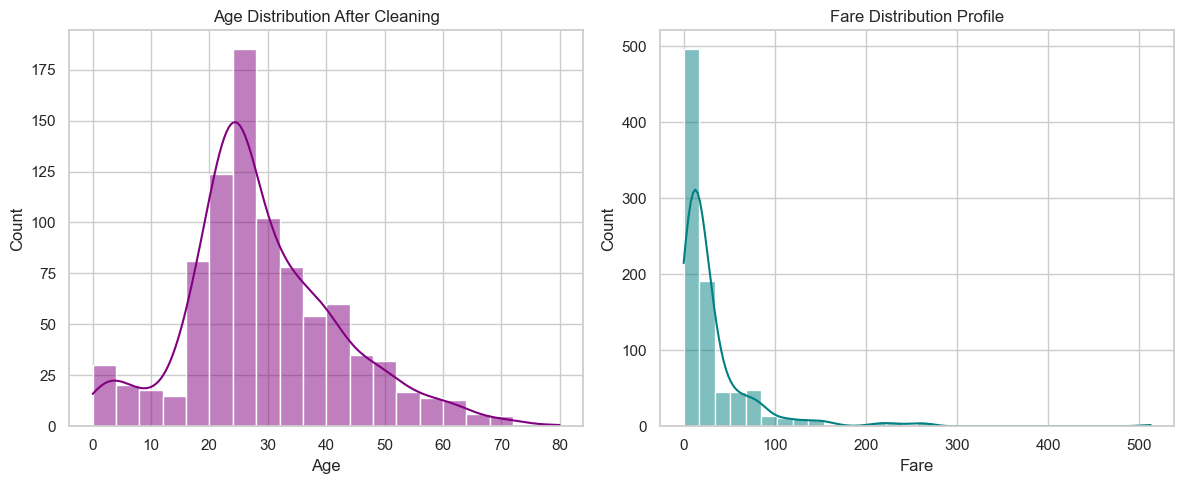

In [12]:
# Plotting distribution plots
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.histplot(raw_df['age'], kde=True, color='purple', bins=20)
plt.title('Age Distribution After Cleaning')
plt.xlabel('Age')

plt.subplot(1, 2, 2)
sns.histplot(raw_df['fare'], kde=True, color='teal', bins=30)
plt.title('Fare Distribution Profile')
plt.xlabel('Fare')

plt.tight_layout()
plt.savefig('images/distribution_plots.png', dpi=100)
plt.show()


## 9. Save Preprocessed Dataset
We save our cleaned dataset to `output/cleaned_titanic.csv` for next-stage analytic models.


In [13]:
# Save file
os.makedirs("output", exist_ok=True)
raw_df.to_csv("output/cleaned_titanic.csv", index=False)
print("Success! Saved cleaned Titanic dataset to output/cleaned_titanic.csv")
print("Dimensions of cleaned dataset:", raw_df.shape)


Success! Saved cleaned Titanic dataset to output/cleaned_titanic.csv
Dimensions of cleaned dataset: (891, 12)


## 10. Conclusion & Project Insights
During this data cleaning and preprocessing pipeline, we successfully transformed the raw Titanic dataset into a highly consistent, structured, and complete version:
1. **Null Values Addressed**: 
   * `Embarked` was filled using its mode.
   * `Age` was imputed intelligently based on `Pclass` and `Sex` subgroups.
   * High-null `Cabin` was mapped to a binary indicator `has_cabin` (retaining status value) and the raw column was dropped.
2. **Duplicates & Types**: Verified no duplicate rows. cast critical columns into `category` and `int` for memory optimization and appropriate modeling interpretations.
3. **Outlier Decisions**: Conducted outliers boxplot analysis and determined that continuous outliers in `Age` and `Fare` are true historical passenger metrics, so they were safely preserved.
